In [3]:
%%time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import gc
import re
import random
import seaborn as sns
from matplotlib.ticker import StrMethodFormatter
import numpy as np

# Pandas DataFrames and Series
pd.set_option("display.float_format",lambda x: f"{x:,.5f}")

# NumPy arrays
np.set_printoptions(suppress=True,precision=6)

plt.rcParams["axes.formatter.useoffset"] = False
plt.rcParams["axes.formatter.limits"] = (-10, 10)

df = pd.read_csv("crypto_master_dataset_imputed.csv")
model_df = df.copy()


CPU times: total: 57.6 s
Wall time: 58.4 s


In [5]:
%%time

# Configuration
HORIZON = 12
TARGET_COL = "target_cumulative_liq_volume_next_12row"
    
# Clean and sort
model_df["timestamp"] = pd.to_datetime(model_df["timestamp"],utc=True,errors="coerce")
model_df["liquidation_volume"] = pd.to_numeric(model_df["liquidation_volume"],errors="coerce")

model_df = (model_df.dropna(subset=["coin","timestamp","price_segment_id","liquidation_volume"])
            .sort_values(["coin","timestamp","price_segment_id"]).reset_index(drop=True))

# Create the cumulative future target
def future_rolling_sum(series, horizon):
    return (series.shift(-1).iloc[::-1].rolling(window=horizon,min_periods=horizon).sum().iloc[::-1])

# Grouping by "price segment" prevents crossing periods of missing price data
model_df[TARGET_COL] = (model_df.groupby(["coin","price_segment_id"],sort=False,observed=True)["liquidation_volume"]
                        .transform(lambda series: future_rolling_sum(series,HORIZON)))

# Any rows without a complete future 12-row window are removed
model_df = (model_df.dropna(subset=[TARGET_COL]).reset_index(drop=True))

# here is another check to ensure the target variable is never negative
model_df[TARGET_COL] = (model_df[TARGET_COL].clip(lower=0).astype("float32"))

# Create common target arrays
y_all = model_df[TARGET_COL].to_numpy(dtype=np.float32)
target = model_df["target_cumulative_liq_volume_next_12row"].dropna()
positive_target = target[target > 0]
zero_positive_counts = [(target == 0).sum(),(target > 0).sum()]

CPU times: total: 18 s
Wall time: 19.3 s


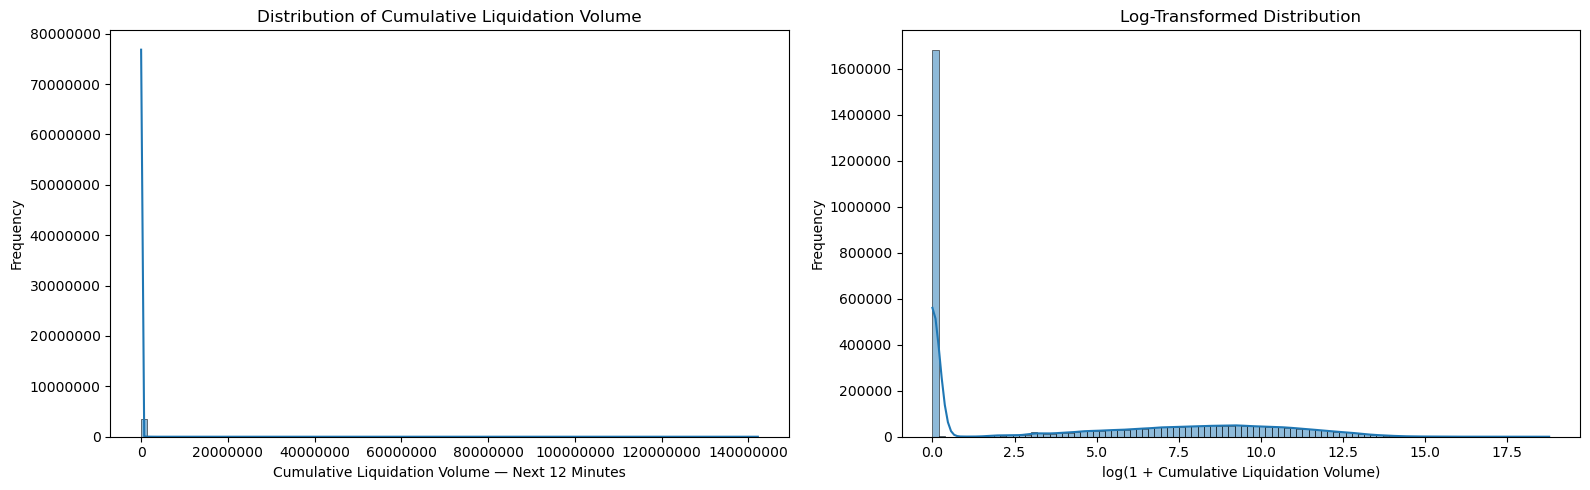

count     3,569,156.00000
mean         37,472.45703
std         456,232.68750
min               0.00000
50%              36.23304
75%           5,774.32520
90%          52,269.32031
95%         142,881.71875
97.5%       298,564.34375
99%         603,061.25938
99.9%     3,159,712.43875
max     142,174,928.00000
Name: target_cumulative_liq_volume_next_12row, dtype: float64


In [6]:

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Original distribution
sns.histplot(target, bins=100, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Cumulative Liquidation Volume")
axes[0].set_xlabel("Cumulative Liquidation Volume — Next 12 Minutes")
axes[0].set_ylabel("Frequency")
axes[0].ticklabel_format(style="plain", axis="x")

# Log-transformed distribution
sns.histplot(np.log1p(target),bins=100,kde=True,ax=axes[1])
axes[1].set_title("Log-Transformed Distribution")
axes[1].set_xlabel("log(1 + Cumulative Liquidation Volume)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

print(target.describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.975, 0.99, 0.999]))

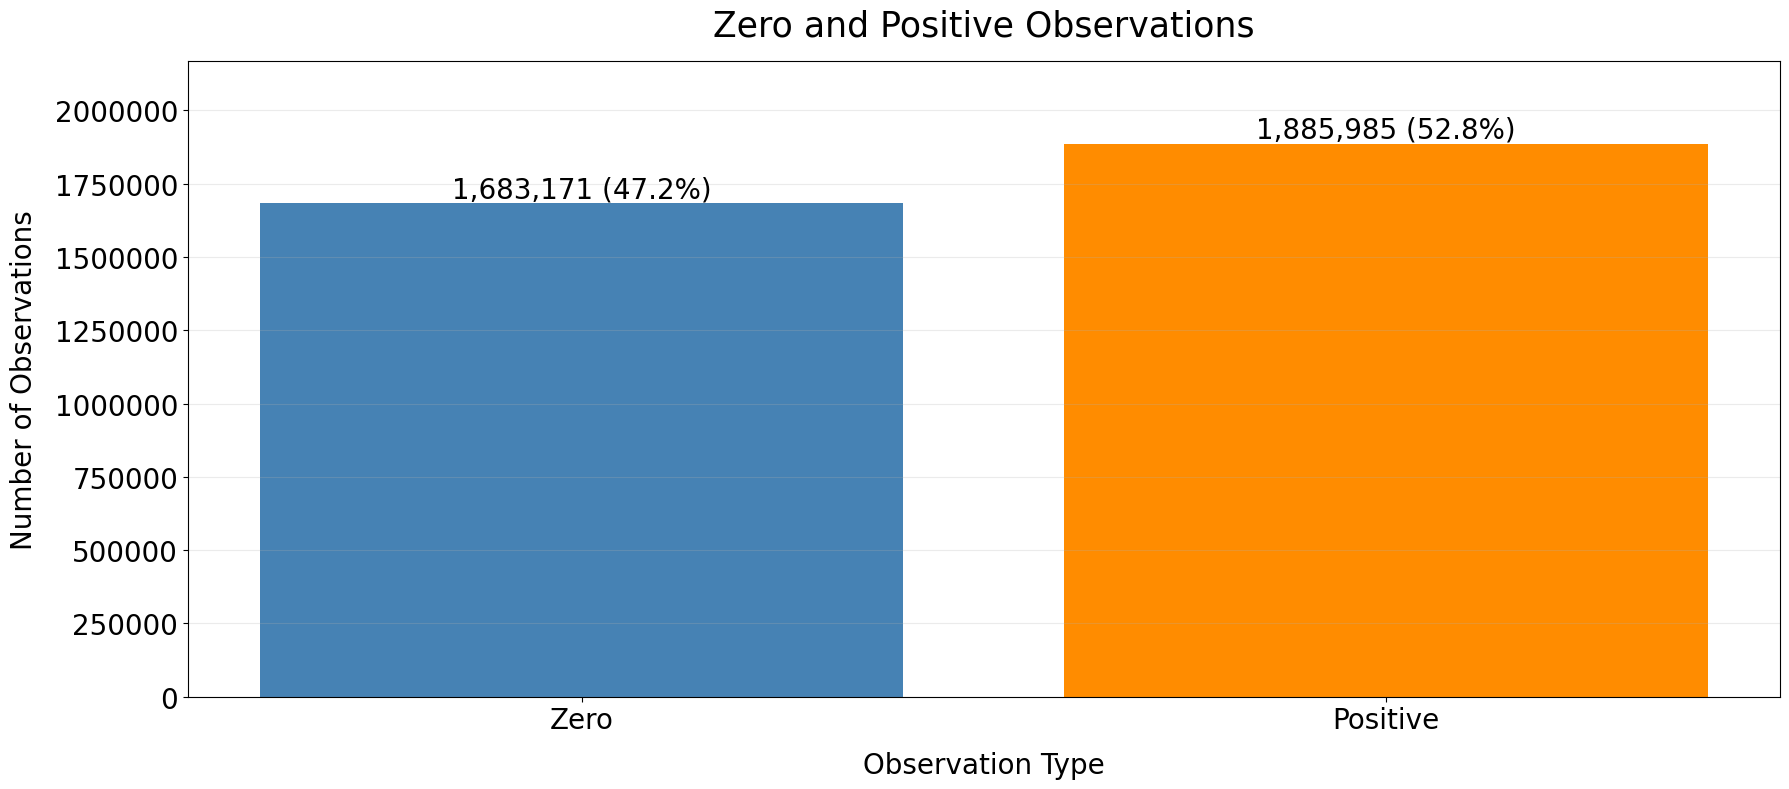

In [7]:

fig, ax = plt.subplots(figsize=(18, 8))
bars = ax.bar(["Zero", "Positive"],zero_positive_counts,color=["steelblue", "darkorange"])
ax.set_title("Zero and Positive Observations",fontsize=25,pad=18)
ax.set_xlabel("Observation Type",fontsize=20,labelpad=12)
ax.set_ylabel("Number of Observations",fontsize=20,labelpad=12)
ax.tick_params(axis="both",labelsize=20)
ax.ticklabel_format(style="plain",axis="y")
ax.set_ylim(0,max(zero_positive_counts) * 1.15)

for bar, count in zip(bars, zero_positive_counts):
    percentage = count / len(target) * 100
    ax.text(bar.get_x() + bar.get_width() / 2,bar.get_height(),f"{count:,} ({percentage:.1f}%)",ha="center",va="bottom",fontsize=20,)

ax.grid(axis="y",alpha=0.25)

plt.tight_layout()
plt.show()

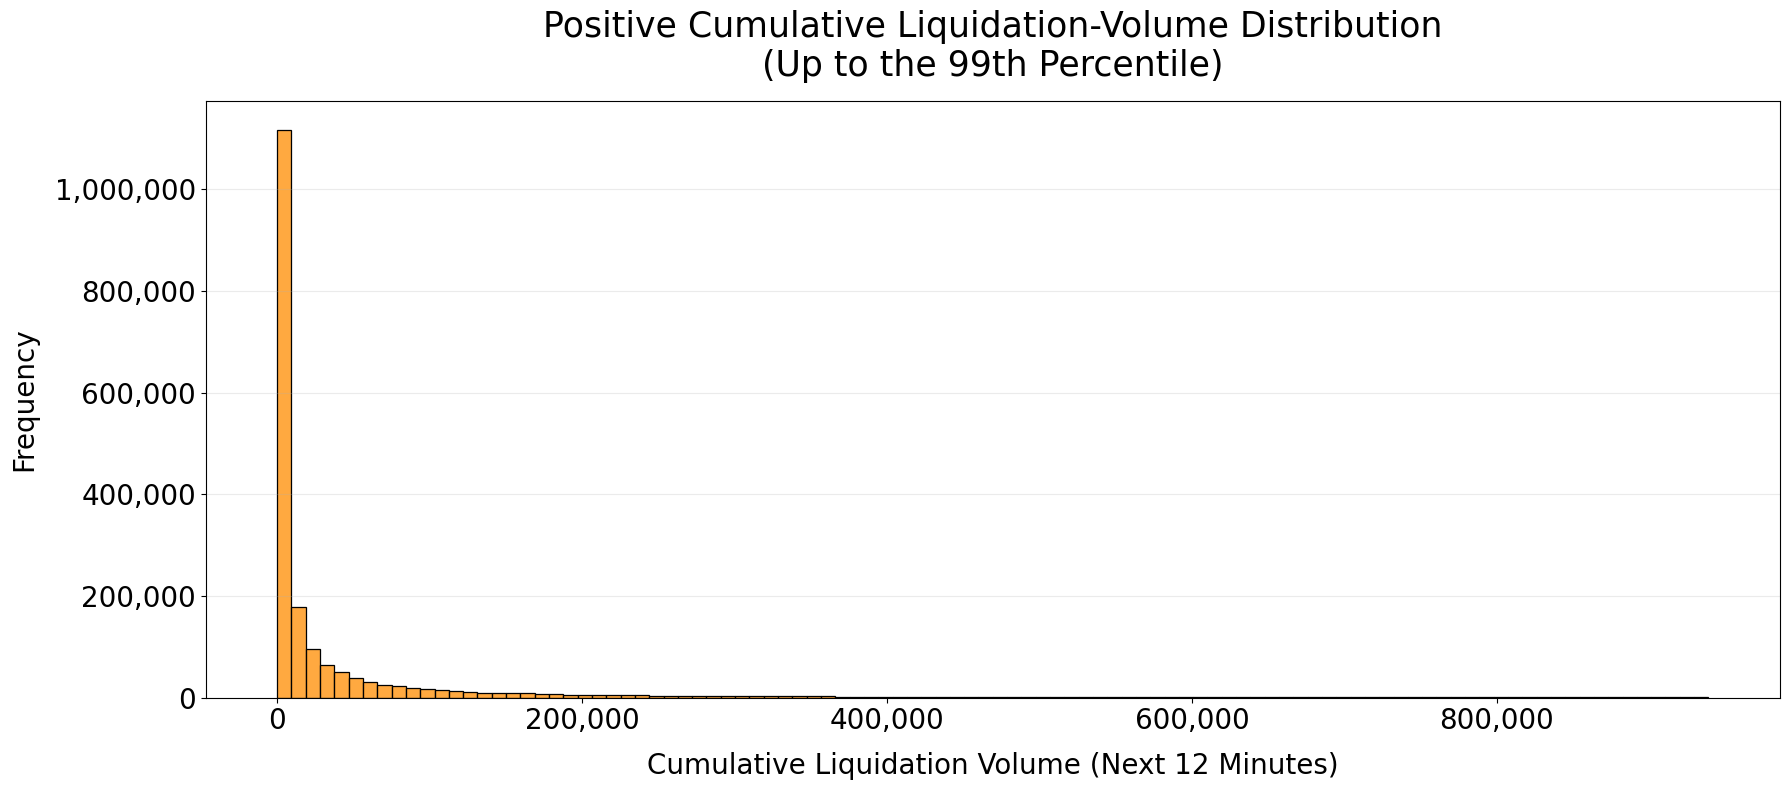

In [8]:

upper_limit = positive_target.quantile(0.99)

fig, ax = plt.subplots(figsize=(18, 8))
sns.histplot(positive_target[positive_target <= upper_limit],bins=100,color="darkorange",ax=ax)

ax.set_title("Positive Cumulative Liquidation-Volume Distribution\n""(Up to the 99th Percentile)",fontsize=25,pad=18)
ax.set_xlabel("Cumulative Liquidation Volume (Next 12 Minutes)",fontsize=20,labelpad=12)
ax.set_ylabel("Frequency",fontsize=20,labelpad=12)
ax.tick_params(axis="both",labelsize=20)
ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.grid(axis="y",alpha=0.25)

plt.tight_layout()
plt.show()

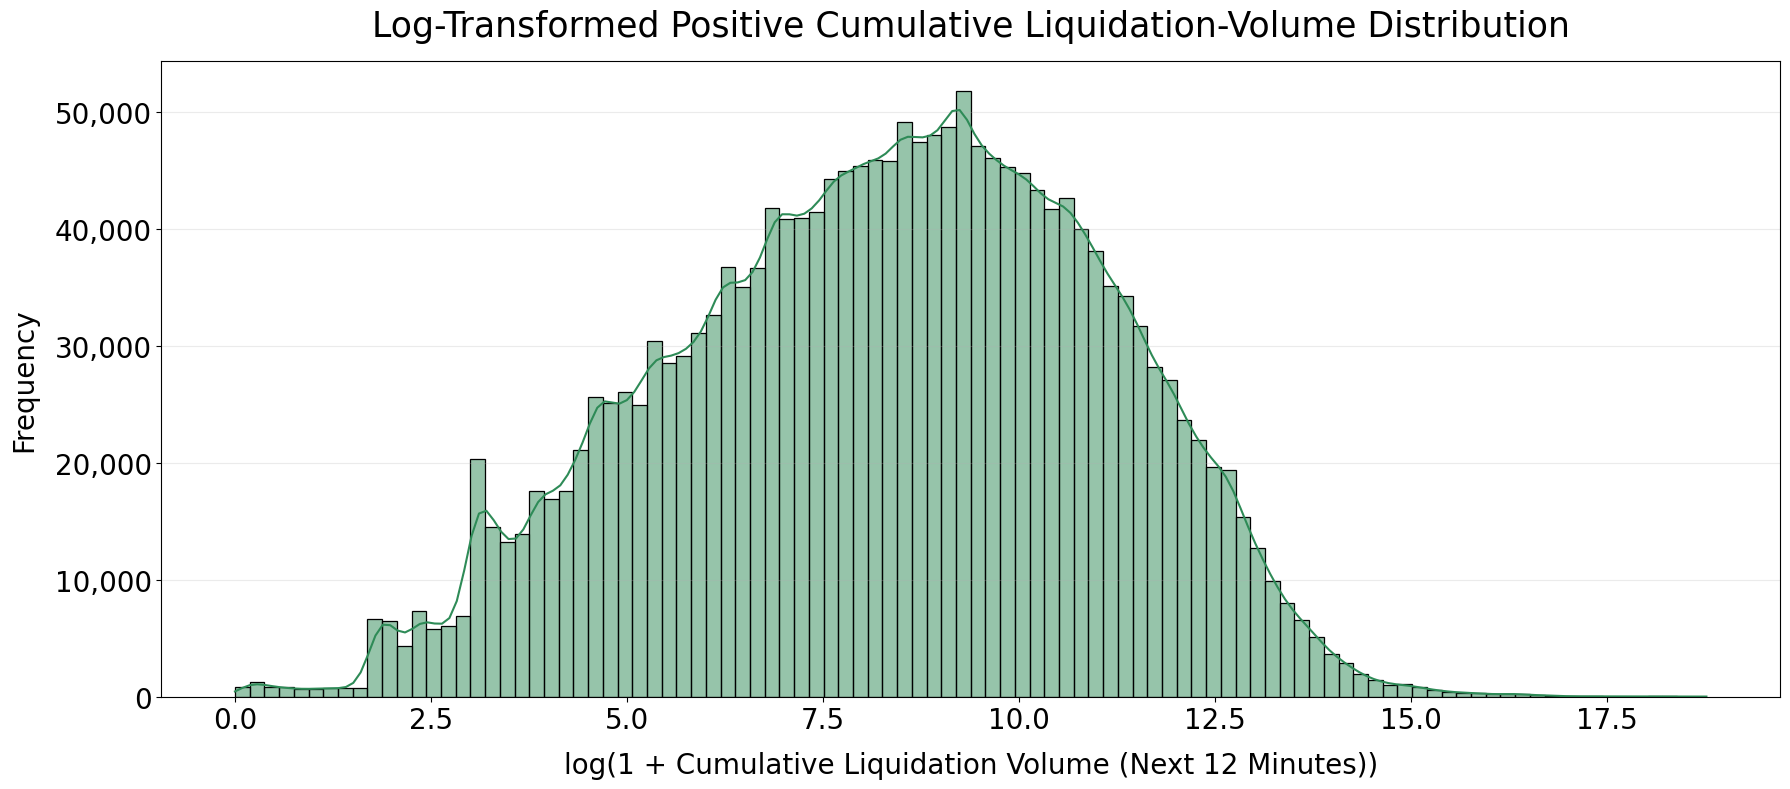

In [9]:
fig, ax = plt.subplots(figsize=(18, 8))
sns.histplot(np.log1p(positive_target),bins=100,kde=True,color="seagreen",ax=ax)

ax.set_title("Log-Transformed Positive Cumulative ""Liquidation-Volume Distribution",fontsize=25,pad=18)
ax.set_xlabel("log(1 + Cumulative Liquidation Volume (Next 12 Minutes))",fontsize=20,labelpad=12)
ax.set_ylabel("Frequency",fontsize=20,labelpad=12)
ax.tick_params(axis="both",labelsize=20)
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.grid(axis="y",alpha=0.25)

plt.tight_layout()
plt.show()

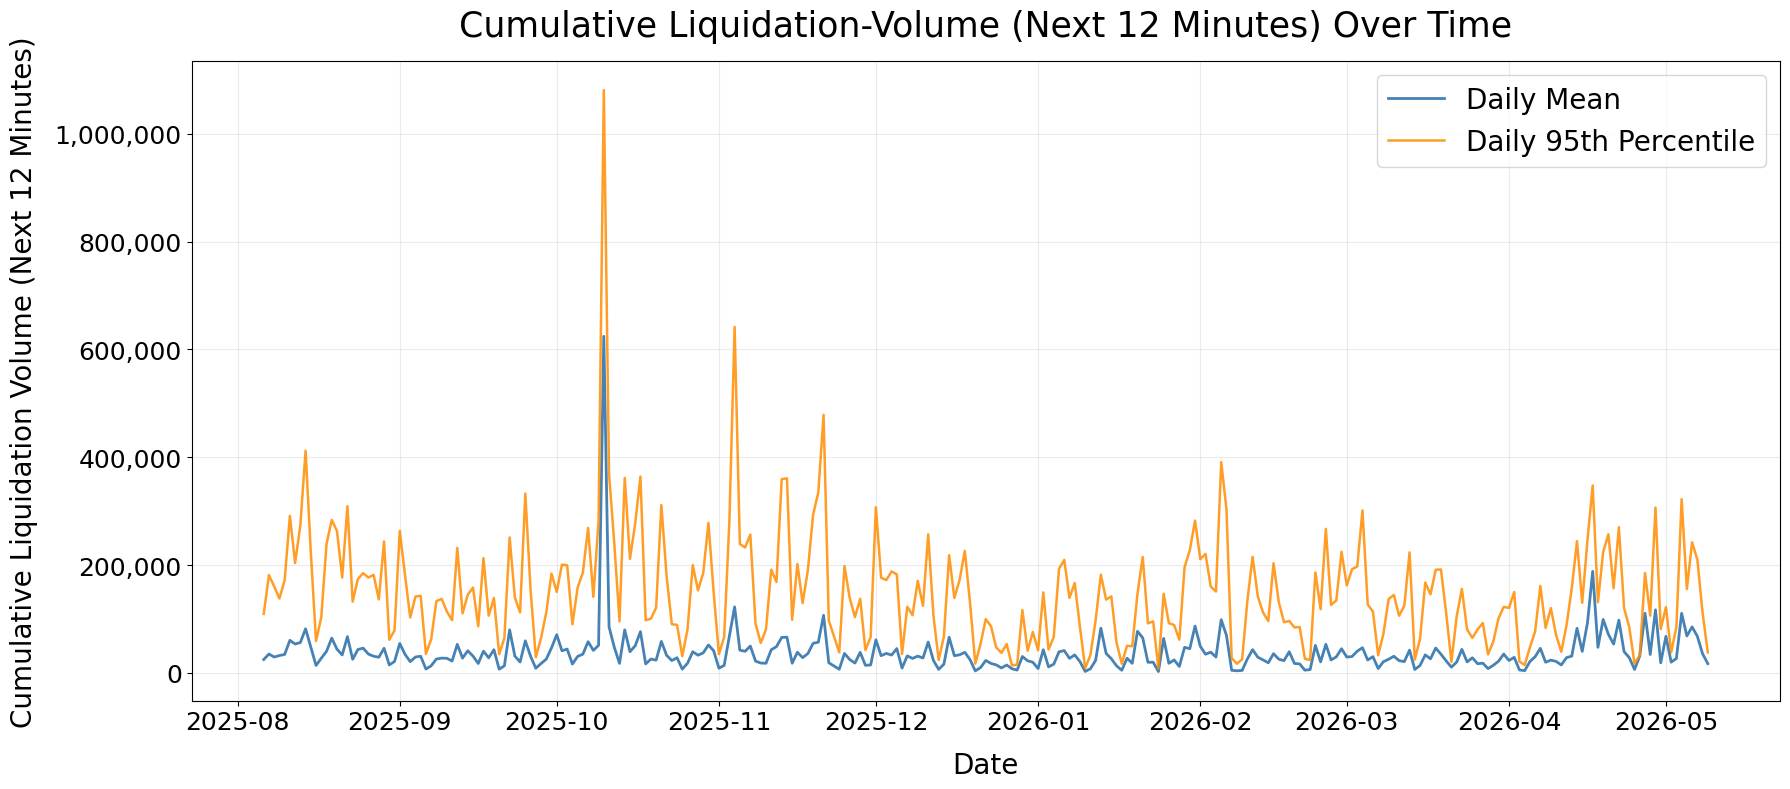

In [11]:
model_df = model_df.dropna(subset=["timestamp","target_cumulative_liq_volume_next_12row"])

daily_volume = (model_df.set_index("timestamp")["target_cumulative_liq_volume_next_12row"].resample("D").
                agg(daily_mean="mean",daily_95th_percentile=lambda x: x.quantile(0.95)))

fig, ax = plt.subplots(figsize=(18, 8))

ax.plot(daily_volume.index,daily_volume["daily_mean"],label="Daily Mean",color="steelblue",linewidth=2.0)
ax.plot(daily_volume.index,daily_volume["daily_95th_percentile"],label="Daily 95th Percentile",color="darkorange",linewidth=1.8,alpha=0.85)

ax.set_title("Cumulative Liquidation-Volume (Next 12 Minutes) Over Time",fontsize=25,pad=18)
ax.set_xlabel("Date",fontsize=20,labelpad=12)
ax.set_ylabel("Cumulative Liquidation Volume (Next 12 Minutes)",fontsize=20,labelpad=12)
ax.tick_params(axis="both",which="major",labelsize=18)
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.legend(fontsize=20,loc="upper right",frameon=True)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()